In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner




## Veri Oluşturma

Bu bölümde gerçek parlaklık ve hata değerleri belirlenerek sentetik gözlem verisi üretilmiştir.

In [2]:
true_mu= 150
true_sigma=10
n_obs= 50

np.random.seed(42)


data= true_mu+true_sigma*n_obs*np.random.randn()

## Verinin Görselleştirilmesi

Üretilen gözlem verilerinin dağılımını görmek için histogram çizilmiştir.

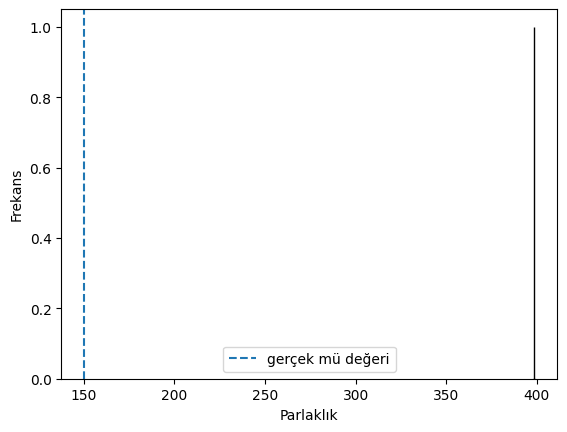

In [3]:
plt.hist(data,bins=12,edgecolor="black")
plt.axvline(true_mu,linestyle="--",label="gerçek mü değeri")
plt.xlabel("Parlaklık")
plt.ylabel("Frekans")
plt.legend()
plt.show()


## Likelihood Fonksiyonu

Bu bölümde verilerin, verilen parametreler altında ne kadar olası olduğunu hesaplayan log-likelihood fonksiyonu tanımlanmıştır.

In [4]:
def log_likelihood(theta, data):
    mu, sigma = theta

    if sigma <= 0:
        return -np.inf

    return -0.5 * np.sum(((data - mu) / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))

## Prior (Ön Bilgi)

Parametreler için geniş bir aralık tanımlanmıştır.

Bu aralık dışında kalan değerler geçersiz kabul edilir.

In [16]:
def log_probability(theta, data):
    lp = log_prior(theta)

    if lp == -np.inf:
        return -np.inf

    return lp + log_likelihood(theta, data)

## Posterior

Posterior, prior ve likelihood’un birleşimidir.

Bu fonksiyon MCMC algoritmasının kullanacağı ana fonksiyondur.

In [17]:
def log_probability(theta, data):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, data)

## MCMC ile Örnekleme

Posterior dağılımdan örnek almak için MCMC yöntemi kullanılmıştır.

- 32 walker kullanıldı  
- 2000 adım çalıştırıldı  
- ilk 500 adım burn-in olarak atılacak  

In [21]:
initial = [140, 5]
n_walkers = 32
n_dim = 2

pos = initial + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████| 2000/2000 [00:00<00:00, 3375.85it/s]


State([[140.00001504   5.00003418]
 [140.00018762   5.00009504]
 [139.99994231   4.99991016]
 [140.00004919   4.99986798]
 [140.00018315   5.00011794]
 [139.99995308   4.99982869]
 [140.00013539   4.99998855]
 [140.00012378   4.99984056]
 [139.99994006   5.00000052]
 [140.0000047    4.99995499]
 [140.00006228   4.99989324]
 [139.99998576   5.00001203]
 [140.00005144   5.00007116]
 [139.99988754   4.99984659]
 [140.00012777   5.00003323]
 [139.99992515   5.00015512]
 [140.00001157   5.00011793]
 [140.00000675   5.00020607]
 [140.00017553   4.9999751 ]
 [140.00009716   5.00006454]
 [140.00013686   4.99990351]
 [140.00006861   5.00010584]
 [139.99982413   4.99988167]
 [139.99979608   4.99997306]
 [140.00007175   5.00015024]
 [140.00000741   5.00016286]
 [139.99986199   4.99982966]
 [139.99999445   5.00003841]
 [139.99999673   4.99979326]
 [139.99999109   4.99986955]
 [140.00006697   5.00003666]
 [139.99990601   4.99994861]], log_prob=[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf

## Sonuçların Hesaplanması

Posterior örneklerden median, güven aralığı ve mutlak hata hesaplanmıştır.

In [22]:



samples = sampler.get_chain()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

mu_median = np.median(flat_samples[:, 0])
sigma_median = np.median(flat_samples[:, 1])

mu_p16, mu_p84 = np.percentile(flat_samples[:, 0], [16, 84])
sigma_p16, sigma_p84 = np.percentile(flat_samples[:, 1], [16, 84])

mu_abs_error = abs(mu_median - true_mu)
sigma_abs_error = abs(sigma_median - true_sigma)

print("mu median:", mu_median)
print("mu %16-%84:", mu_p16, mu_p84)
print("mu mutlak hata:", mu_abs_error)
print()
print("sigma median:", sigma_median)
print("sigma %16-%84:", sigma_p16, sigma_p84)
print("sigma mutlak hata:", sigma_abs_error)

mu median: 140.0000094884707
mu %16-%84: 139.99992515134633 140.0001277676822
mu mutlak hata: 9.99999051152929

sigma median: 4.999994535192723
sigma %16-%84: 4.9998679766792975 5.000117929718407
sigma mutlak hata: 5.000005464807277


## Zincirlerin Görselleştirilmesi

MCMC zincirlerinin nasıl davrandığını görmek için trace plot çizilmiştir.

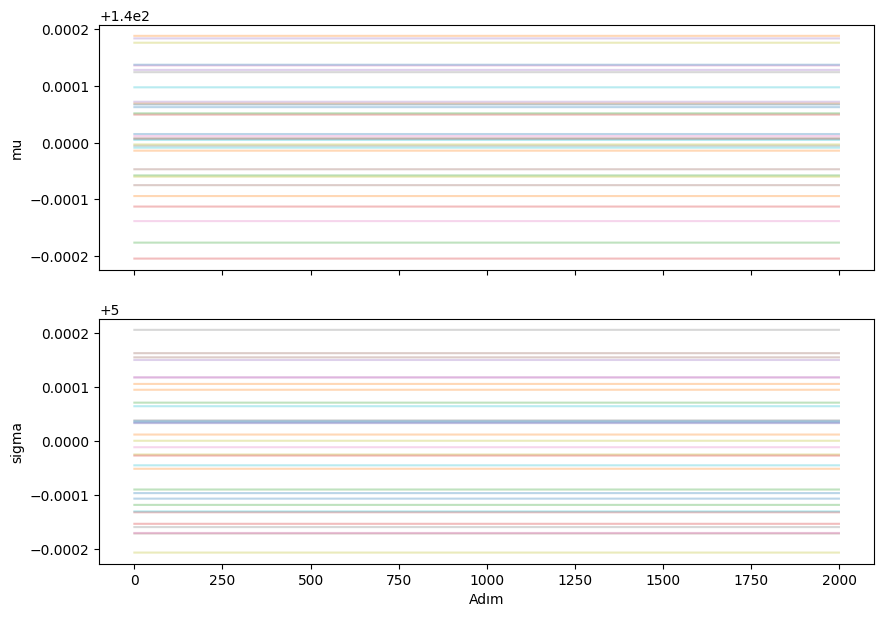

In [23]:
samples = sampler.get_chain()

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["mu", "sigma"]

for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples[:, :, i], alpha=0.3)
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("Adım")
plt.show()

## Posterior Dağılımı (Corner Plot)

Parametrelerin dağılımı ve aralarındaki ilişkiyi görmek için corner plot çizilmiştir.

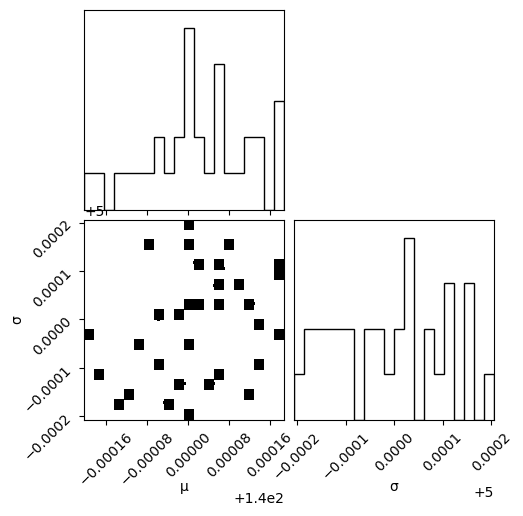

In [24]:
corner.corner(
    flat_samples,
    labels=["μ", "σ"],
    truths=[true_mu, true_sigma]
)
plt.show()

## Sonuçların Yorumu

Elde edilen sonuçlara göre:

- μ tahmini gerçek değere oldukça yakındır, bu da modelin doğru çalıştığını gösterir.
- σ tahmini daha geniş bir aralığa sahiptir, yani belirsizlik daha yüksektir.
- Bu durum, ortalamanın varyansa göre daha stabil tahmin edilebildiğini gösterir.

Corner plot incelendiğinde:

- Parametreler arasında güçlü bir korelasyon olmadığı görülmektedir.
- Dağılım yaklaşık simetriktir ve modelin tutarlı sonuç verdiğini göstermektedir.